# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isnull().sum())# Cantidad de valores nulos)
print(users.isnull().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  



En `users`, la columna `city` presenta 469 valores nulos, equivalentes al **11,725 %** de los registros. Se decide **mantener (`keep`), estos valores como `NA`**, estandanzarizando los nulos. Ya que eliminar aproximadamente el 11,7 % de los usuarios reduciría considerablemente la muestra y podría introducir sesgo. 


La columna `churn_date` presenta 3.534 valores nulos, equivalentes al **88,350 %**. En este caso también se decide **mantener (`keep`) los nulos**, porque la ausencia de una fecha de abandono puede representar que el usuario continúa activo. Eliminar estos registros supondría perder el 88,35 % de los usuarios y distorsionaría completamente el análisis. 

En `usage`, la columna `date` tiene únicamente 50 valores nulos, equivalentes al **0,125 %**. Como la fecha es necesaria para comprobar el periodo temporal del análisis y no existe una fecha correcta con la cual imputar estos registros, se decide **eliminar (`drop`) esas filas**. La pérdida de información es mínima.

La columna `duration` tiene 22.076 valores nulos (**55,190 %**). No se deben eliminar ni imputar automáticamente. Primero se comprueba si los nulos dependen de `type`. Si se observa que `duration` solo corresponde a registros de tipo `call`, los valores ausentes en registros `text` son estructurales y representan una variable que no aplica. Por ello se decide **mantener (`keep`) los nulos**.

La columna `length` tiene 17.896 valores nulos (**44,740 %**). De forma análoga, se comprueba su relación con `type`. Si `length` corresponde únicamente a mensajes, los valores nulos en llamadas son estructurales. Por ello se decide **mantener (`keep`) los nulos**, en lugar de convertirlos artificialmente en cero o eliminar registros.

En resumen, se utiliza `drop` únicamente para los 50 registros sin fecha porque son una proporción mínima y la variable es necesaria para el análisis temporal. Los demás nulos se mantienen porque contienen información estructural o porque eliminarlos produciría una pérdida importante de observaciones.


In [27]:
#Mantener columna City y reemplazar nulos
users['city'] = users['city'].replace('?', pd.NA)
#Eliminar columna Date
usage = usage.dropna(subset=['date']).copy()
#Verificar
print('Filas de usage después de drop de fechas nulas:', len(usage))

Filas de usage después de drop de fechas nulas: 39950


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no tiene sentinels
- La columna `age` en este caso tiene un sentinel evidente ya que tiene edades de -999 lo cual es imposible

In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id` no tienen anomalias o sentinels evidentes

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].value_counts(dropna=False))



Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene varios valores nulos
- La columna `plan` no contiene valores faltantes

In [15]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))
print("\nCategorías únicas:", usage['type'].dropna().unique())

text    22092
call    17908
Name: type, dtype: int64

Categorías únicas: ['call' 'text']


- La columna `type` identifica el tipo de interacción. En el dataset se esperan los tipos call y text. Esta columna es especialmente importante para interpretar los nulos de duration y length, porque esas variables no aplican de la misma manera a llamadas y mensajes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- 
El principal sentinel se encuentra en `age` siendo una edad de -999. En `city` se encontraron valores nulos y en el resto de columnas no se evidenciaron valores invalidos


In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` y `date`, la conversión con errors='coerce' transforma fechas no interpretables en NaT
Ademas años posteriores al 2024 no deben tomarse en cuenta ya que el analisis que realizamos llega hasta el 31 de diciembre de 2024


In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, Se revisan los años antes de analizar el uso. Los registros posteriores a 2024 no forman parte del periodo definido por el proyecto y se marcarán como NaT. Los registros sin fecha ya fueron eliminados porque no permiten comprobar el periodo temporal

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Aparecen fechas posteriores a 2024. Estas fechas identificadas como imposibles o fuera de rango las convertí en valores nulos (pd.NA/NaT) en lugar de eliminarlas inmediatamente. De esta manera, se conserva la fila y se reconoce explícitamente que la fecha original no es válida. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'].ne(-999), 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [28]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print('Valores nulos en city:', users['city'].isna().sum())
print(users['city'].value_counts(dropna=False))

Valores nulos en city: 565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [29]:
# Marcar fechas futuras como NA para reg_date
limite_2024 = pd.Timestamp('2024-12-31 23:59:59')
users.loc[users['reg_date'] > limite_2024, 'reg_date'] = pd.NaT

# Verificar cambios
print('Fechas reg_date fuera de rango:', users['reg_date'].isna().sum())
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

Fechas reg_date fuera de rango: 40
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [30]:
# Verificación MAR en usage (Missing At Random) para duration
duration_missing = usage['duration'].isna()
mar_duration = pd.crosstab(usage['type'], duration_missing, normalize='index').mul(100).round(2)
print('Porcentaje de duration faltante por tipo:')
print(mar_duration)

Porcentaje de duration faltante por tipo:
duration   False  True 
type                   
call      100.00   0.00
text        0.07  99.93


In [31]:
# Verificación MAR en usage (Missing At Random) para length
length_missing = usage['length'].isna()
mar_length = pd.crosstab(usage['type'], length_missing, normalize='index').mul(100).round(2)
print('Porcentaje de length faltante por tipo:')
print(mar_length)

print('\nPromedio de length por tipo:')
print(usage.groupby('type')['length'].mean())

Porcentaje de length faltante por tipo:
length   False  True 
type                 
call      0.07  99.93
text    100.00   0.00

Promedio de length por tipo:
type
call    1490.000000
text      51.351187
Name: length, dtype: float64


Si la tabla de contingencia muestra que duration falta en los registros text y está presente en call, mientras que length sigue el patrón inverso, los nulos no son errores aleatorios: son nulos estructurales condicionados por type. En la terminología solicitada por el ejercicio, esto se interpreta como dependencia de una variable observada (MAR).

Por eso se usa keep: eliminar estas filas destruiría registros válidos de mensajes o llamadas, y rellenar con una media introduciría valores ficticios. Tampoco se usa cap, porque cap es una estrategia para valores extremos, no para valores faltantes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
         .agg(
             cant_mensajes=('is_text', 'sum'),
             cant_llamadas=('is_call', 'sum'),
             cant_minutos_llamada=('duration', 'sum')
         )
         .reset_index()
)

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Observar resultado
print(usage_agg.columns.tolist())
print(usage_agg.dtypes)
usage_agg.head(3)


['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_id                   int64
cant_mensajes             int64
cant_llamadas             int64
cant_minutos_llamada    float64
dtype: object


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Resumen estadístico de las columnas numéricas
columnas_estadisticas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen_numerico = user_profile[columnas_estadisticas].describe().T
resumen_numerico['mediana'] = user_profile[columnas_estadisticas].median()
resumen_numerico['asimetria'] = user_profile[columnas_estadisticas].skew()
resumen_numerico


,count,mean,std,min,25%,50%,75%,max,mediana,asimetria
age,4000.0,48.136000,17.689919,18.0,33.000,48.00,63.000,79.00,48.00,0.047469
cant_mensajes,3999.0,5.518380,2.358046,0.0,4.000,5.00,7.000,17.00,5.00,0.458384
cant_llamadas,3999.0,4.471618,2.142878,0.0,3.000,4.00,6.000,15.00,4.00,0.505739
cant_minutos_llamada,3999.0,23.288867,18.161719,0.0,11.085,19.77,31.355,155.69,19.77,2.530870


In [36]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True).mul(100).round(2)
print(distribucion_plan)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

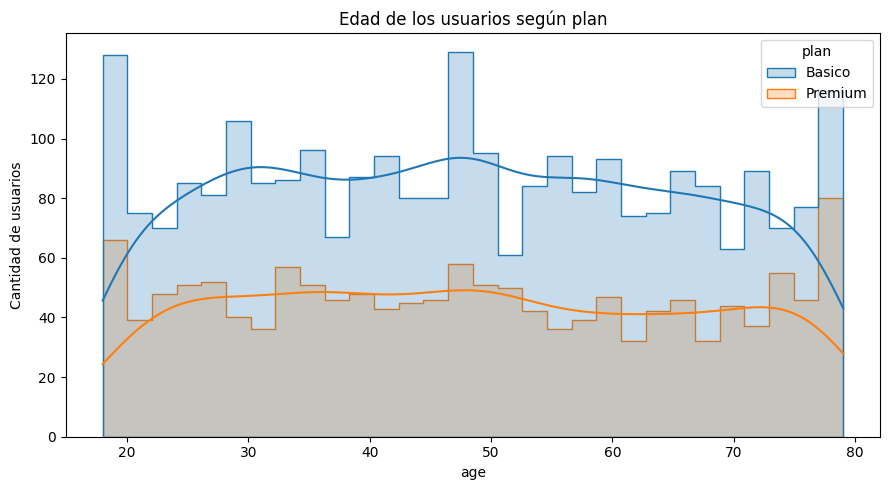

In [37]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='age', hue='plan', bins=30, kde=True, element='step', stat='count', common_norm=False)
plt.title('Edad de los usuarios según plan')
plt.xlabel('age')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

💡Insights:

-La forma exacta de la distribución se observa en el histograma. Para no inventar un resultado antes de ejecutar el notebook, la celda anterior permite comparar directamente Básico vs. Premium y la celda de estadísticas del Paso 4.2 aporta media, mediana y asimetría. Una distribución con media mayor que mediana y asimetría positiva presenta sesgo a la derecha; si son cercanas y la asimetría es próxima a cero, es aproximadamente simétrica.


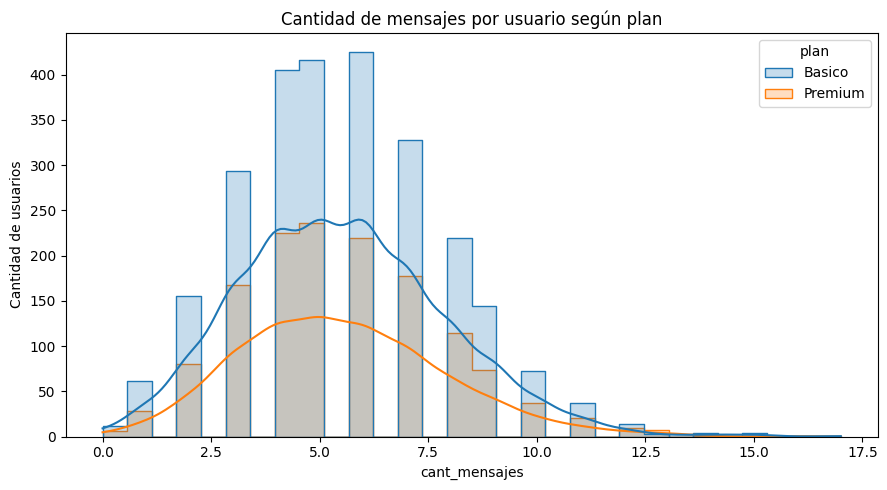

In [38]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=30, kde=True, element='step', stat='count', common_norm=False)
plt.title('Cantidad de mensajes por usuario según plan')
plt.xlabel('cant_mensajes')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

💡Insights: 
- Se debe comparar la concentración de mensajes entre planes y observar la cola derecha. En variables de conteo de uso es normal encontrar muchos usuarios con pocos eventos y una cola de usuarios con mayor actividad; la forma concreta debe verificarse en el gráfico y en la asimetría calculada.

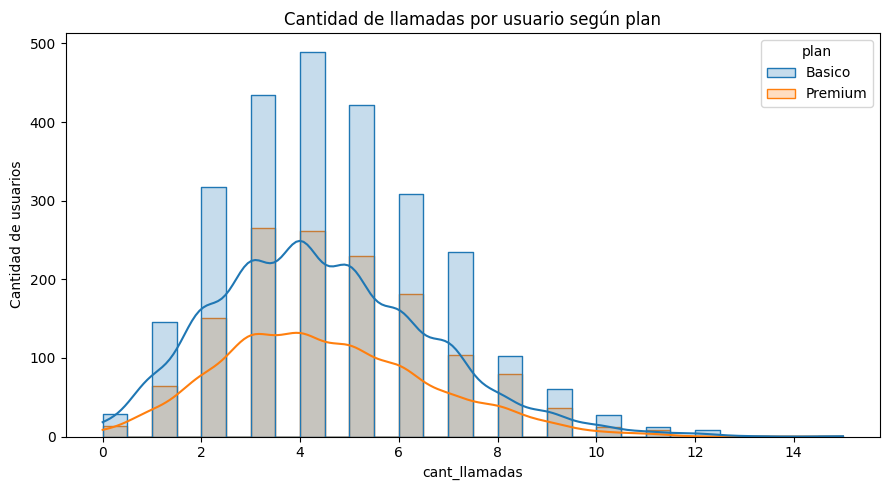

In [39]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=30, kde=True, element='step', stat='count', common_norm=False)
plt.title('Cantidad de llamadas por usuario según plan')
plt.xlabel('cant_llamadas')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

💡Insights: 
- El histograma permite comprobar si los planes presentan patrones de llamadas diferentes. La asimetría y la distancia entre media y mediana ayudan a determinar si existe una cola de usuarios con consumo elevado.

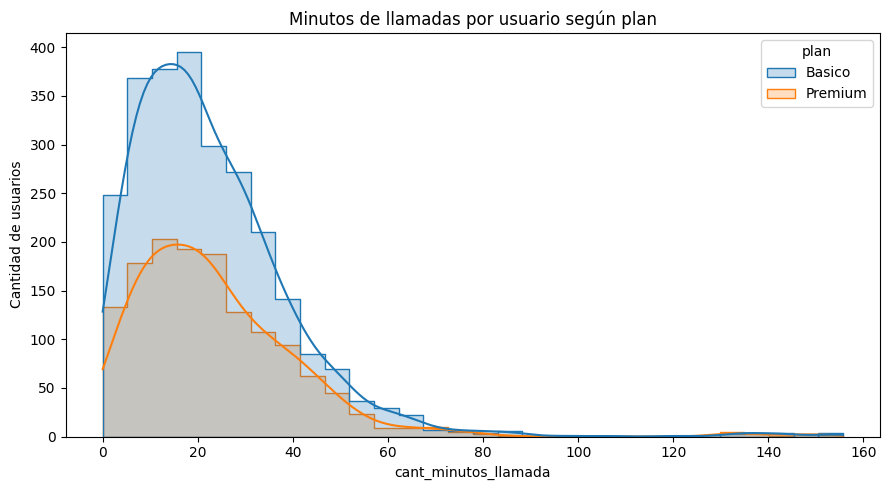

In [40]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=30, kde=True, element='step', stat='count', common_norm=False)
plt.title('Minutos de llamadas por usuario según plan')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

💡Insights: 
- Los minutos acumulados pueden presentar una cola derecha si una parte pequeña de los clientes concentra muchas llamadas o llamadas largas. La conclusión concreta debe apoyarse en el histograma y en la asimetría de la tabla estadística.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

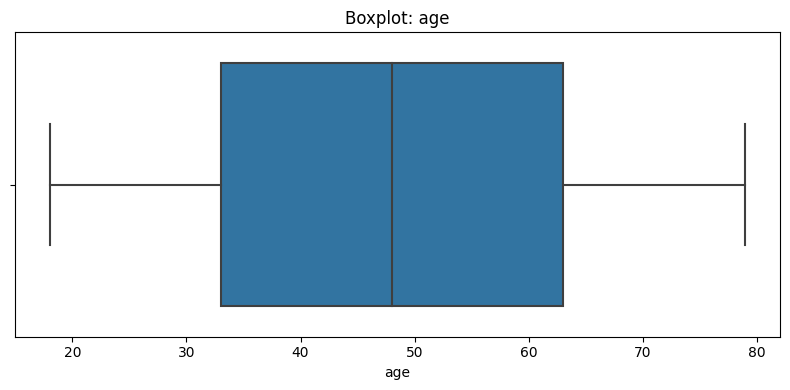

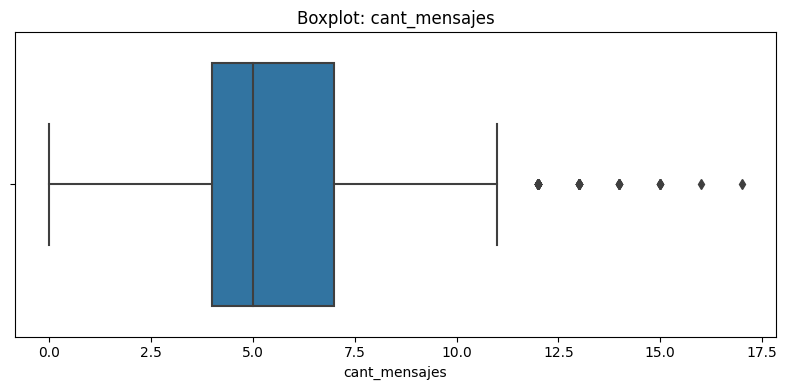

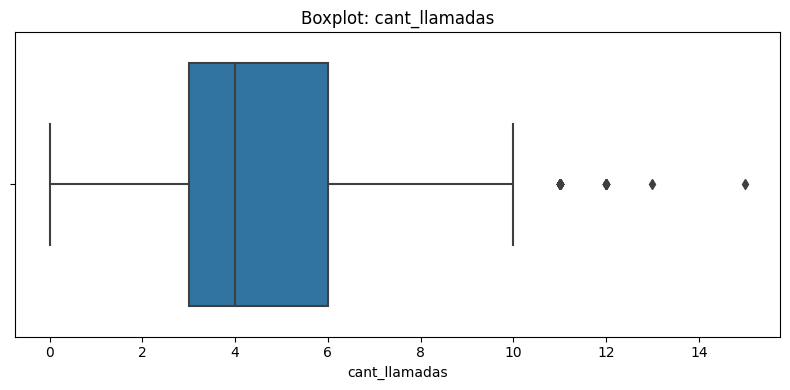

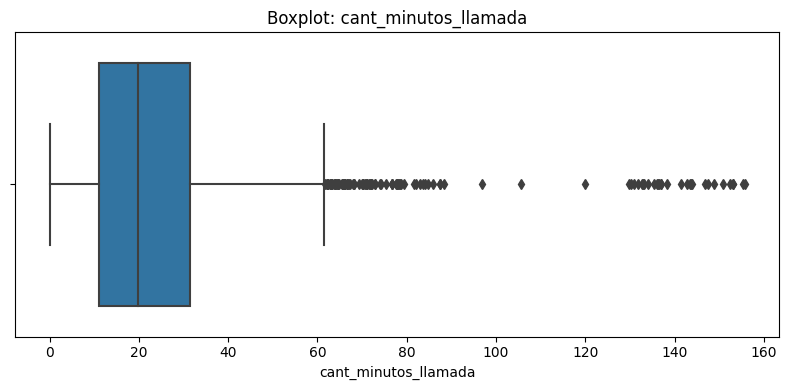

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights: 

age: presenta algunos valores que pueden aparecer como outliers después de corregir el sentinel -999. Sin embargo, no deben considerarse errores automáticamente, ya que una edad extrema puede ser estadísticamente poco frecuente pero válida. Por ello, se decide keep y no eliminarla.

cant_mensajes: presenta outliers superiores, correspondientes a usuarios con una cantidad de mensajes considerablemente mayor que la mayoría. Como estos valores pueden representar un comportamiento real de uso, se decide keep y no eliminarlos.

cant_llamadas: presenta outliers superiores, correspondientes a usuarios con un número de llamadas elevado. Al tratarse de una métrica de consumo, estos valores pueden ser reales y relevantes para el análisis, por lo que se decide keep.

cant_minutos_llamada: presenta outliers superiores, asociados a usuarios que acumulan una cantidad de minutos de llamadas mucho mayor que el resto. Como no existe evidencia de que sean errores de captura, se decide keep.

En conclusión, los outliers detectados mediante el boxplot y posteriormente evaluados con el método IQR no se eliminan ni se capan, porque representan posibles patrones reales de consumo. cap solo sería necesario si existiera evidencia de que los valores extremos son errores o si estuvieran distorsionando significativamente el análisis.

In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

limites_iqr = {}
for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    limites_iqr[col] = {'Q1': q1, 'Q3': q3, 'IQR': iqr,
                        'limite_inferior': limite_inferior,
                        'limite_superior': limite_superior,
                        'maximo': user_profile[col].max()}

limites_iqr = pd.DataFrame(limites_iqr).T
limites_iqr

,Q1,Q3,IQR,limite_inferior,limite_superior,maximo
cant_mensajes,4.000,7.000,3.00,-0.50,11.50,17.00
cant_llamadas,3.000,6.000,3.00,-1.50,10.50,15.00
cant_minutos_llamada,11.085,31.355,20.27,-19.32,61.76,155.69


In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
limites_iqr[['limite_superior', 'maximo']]

,limite_superior,maximo
cant_mensajes,11.50,17.00
cant_llamadas,10.50,15.00
cant_minutos_llamada,61.76,155.69


💡Insights: 
- cant_mensajes: Mantener. No hay evidencia, solo por ser altos, de que sean errores.
- cant_llamadas: Mantener. No hay evidencia, solo por ser altos, de que sean errores.
- cant_minutos_llamada: Mantener. No hay evidencia, solo por ser altos, de que sean errores.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

user_profile['grupo_uso'].value_counts()

Uso medio    2941
Bajo uso      780
Alto uso      279
Name: grupo_uso, dtype: int64

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [46]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

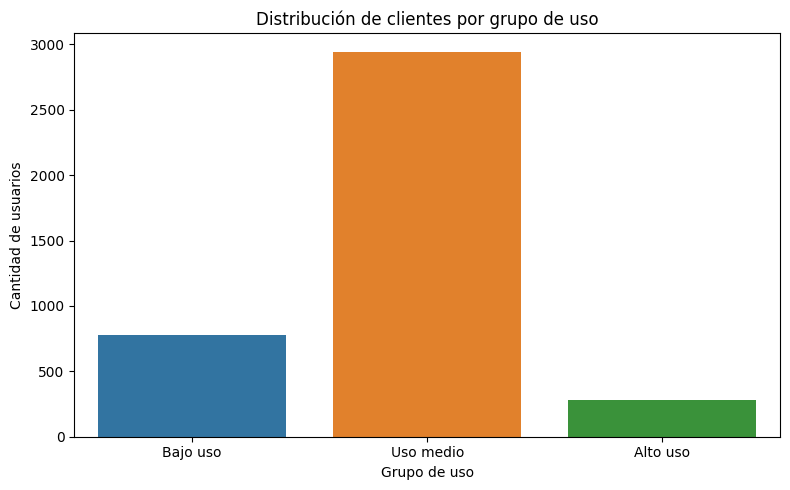

In [48]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

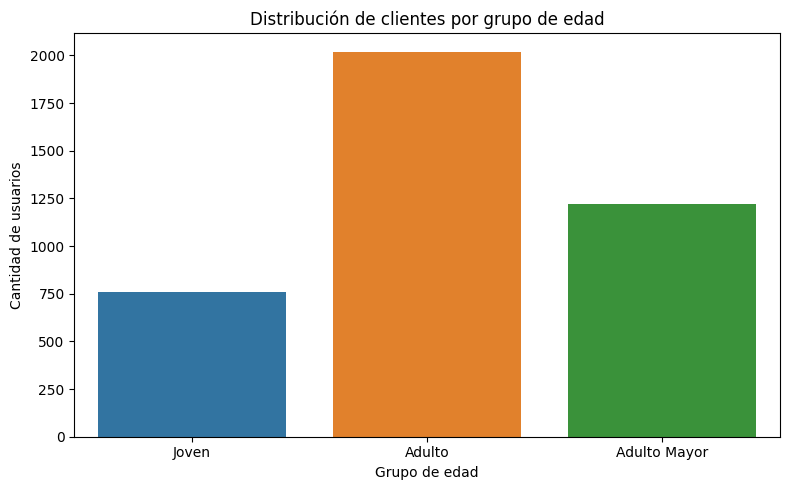

In [49]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
 - `users.city`: 469 valores faltantes (11,725 %). Se conserva con keep después de transformar `?` en `pd.NA` para no perder clientes.
 - `users.churn_date`: 3534 valores faltantes (88,350 %). Se conservan porque la ausencia de fecha de abandono puede representar clientes sin churn registrado.
 - `users.age`: contiene el sentinel `-999`; se reemplaza por la mediana de las edades válidas, siguiendo la instrucción del proyecto.
- `usage.date`: 50 valores faltantes (0,125 %). Se eliminan con drop porque sin fecha no puede comprobarse el periodo y la pérdida es mínima.
 - `usage.duration` y `usage.length`: sus nulos dependen del tipo de interacción; se conservan como nulos estructurales/MAR según la metodología del ejercicio.


🔍 **Segmentos por Edad**
- Se crean Joven (<30), Adulto (30–59) y Adulto Mayor (60 o más). La distribución exacta se obtiene con value_counts() y el gráfico del Paso 6.3.



📊 **Segmentos por Nivel de Uso**
- Se crean `Bajo uso` (llamadas <5 y mensajes <5), `Uso medio` (llamadas <10 y mensajes <10) y `Alto uso` para el resto. La distribución exacta se obtiene con `value_counts()` y el gráfico

➡️ Esto sugiere que ...
- Los segmentos permiten diferenciar clientes según intensidad de uso y edad. Los usuarios de mayor uso pueden requerir mayor capacidad de llamadas/mensajes, mientras que los de bajo uso pueden tener necesidades distintas. La decisión comercial debe apoyarse en los conteos y estadísticas generados por el notebook, no solo en la categoría.


💡 **Recomendaciones**
- Revisar si los límites de los planes cubren adecuadamente el consumo observado en cada segmento.
- Usar a los clientes de alto consumo para estudiar si los límites de minutos, mensajes o datos generan cargos adicionales.
- Considerar ofertas diferenciadas por comportamiento, evitando asumir que todos los clientes de una misma edad tienen el mismo consumo.
- Mantener la trazabilidad de los datos faltantes y no reemplazar valores estructuralmente ausentes por números artificiales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/MikeAlvar/telecom-analysis-S7`